# 📊 Trực quan hóa dữ liệu toàn diện với Matplotlib & Seaborn

Notebook này minh họa **hầu hết các loại biểu đồ phổ biến** của hai thư viện:
- `matplotlib.pyplot` — line, bar, scatter, histogram, pie, boxplot, area, subplots, heatmap, 3D, ...
- `seaborn` — relational, distribution, categorical, matrix, regression, multi-plot (Facet) ...

**Bộ dữ liệu:** `sample_sales_data.csv` — dữ liệu bán hàng tổng hợp (tự tạo bằng NumPy/Pandas) gồm 2000 dòng, mô phỏng doanh số theo thời gian, khu vực, danh mục sản phẩm, khách hàng...

> 💡 Chạy lần lượt từng cell từ trên xuống dưới.

## 1. Import thư viện & cấu hình chung

In [1]:
# Thư viện xử lý dữ liệu
import numpy as np
import pandas as pd

# Matplotlib - toàn bộ các module thường dùng
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D  # bắt buộc để bật vẽ 3D

# Seaborn
import seaborn as sns

# Cấu hình hiển thị
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)

print("matplotlib:", mpl.__version__)
print("seaborn   :", sns.__version__)
print("pandas    :", pd.__version__)
print("numpy     :", np.__version__)

matplotlib: 3.10.8
seaborn   : 0.13.2
pandas    : 3.0.2
numpy     : 2.4.4


## 2. Đọc dữ liệu

File `sample_sales_data.csv` được tạo sẵn (script tạo dữ liệu nằm ở cuối notebook, mục 9) mô phỏng dữ liệu bán lẻ:

| Cột | Ý nghĩa |
|---|---|
| Date | Ngày bán |
| Region | Khu vực (North/South/East/West/Central) |
| Category | Danh mục sản phẩm |
| Product | Tên sản phẩm |
| Quantity | Số lượng bán |
| Unit_Price | Đơn giá |
| Discount_Percent | % giảm giá |
| Sales_Amount | Doanh thu |
| Profit | Lợi nhuận |
| Customer_Age | Tuổi khách hàng |
| Customer_Rating | Đánh giá (1-5) |
| Payment_Method | Phương thức thanh toán |
| Channel | Online / In-Store |

In [2]:
df = pd.read_csv("sample_sales_data.csv", parse_dates=["Date"])
df["Month"] = df["Date"].dt.to_period("M").astype(str)
df["Year"] = df["Date"].dt.year
print(df.shape)
df.head()

(2000, 15)


,Date,Region,Category,Product,Quantity,Unit_Price,Discount_Percent,Sales_Amount,Profit,Customer_Age,Customer_Rating,Payment_Method,Channel,Month,Year
0,2023-01-01,South,Furniture,Table,6,348.92,0,2929.70,766.72,30,4.5,Cash,Online,2023-01,2023
1,2023-01-01,Central,Food,Dairy,9,24.59,5,294.19,60.87,29,5.0,Credit Card,In-Store,2023-01,2023
2,2023-01-01,West,Furniture,Chair,6,262.08,15,1870.51,752.79,47,4.8,E-Wallet,Online,2023-01,2023
3,2023-01-02,East,Clothing,T-Shirt,6,54.20,5,432.41,181.30,21,4.8,Cash,In-Store,2023-01,2023
4,2023-01-02,North,Clothing,Shoes,8,57.40,0,642.74,266.93,39,3.9,E-Wallet,In-Store,2023-01,2023


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,2000,NaN,NaN,NaN,2023-12-31 12:00:43.200000,2023-01-01 00:00:00,2023-07-02 00:00:00,2023-12-31 12:00:00,2024-07-01 00:00:00,2024-12-31 00:00:00,NaN
Region,2000,5,North,527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,2000,5,Food,419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,2000,20,Headphones,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,2000.0,NaN,NaN,NaN,6.0335,1.0,4.0,6.0,7.0,17.0,2.256086
Unit_Price,2000.0,NaN,NaN,NaN,184.36748,20.15,36.18,62.99,355.135,584.79,182.504429
Discount_Percent,2000.0,NaN,NaN,NaN,7.75,0.0,0.0,5.0,15.0,25.0,7.683881
Sales_Amount,2000.0,NaN,NaN,NaN,1062.371535,18.44,181.7175,375.91,1647.0525,11902.55,1314.82785
Profit,2000.0,NaN,NaN,NaN,342.660325,5.9,56.865,122.33,516.5575,3803.41,439.796605
Customer_Age,2000.0,NaN,NaN,NaN,37.8615,18.0,29.0,37.0,46.0,75.0,12.121212


## 3. Matplotlib — Biểu đồ cơ bản

### 3.1 Line plot — Doanh thu theo thời gian

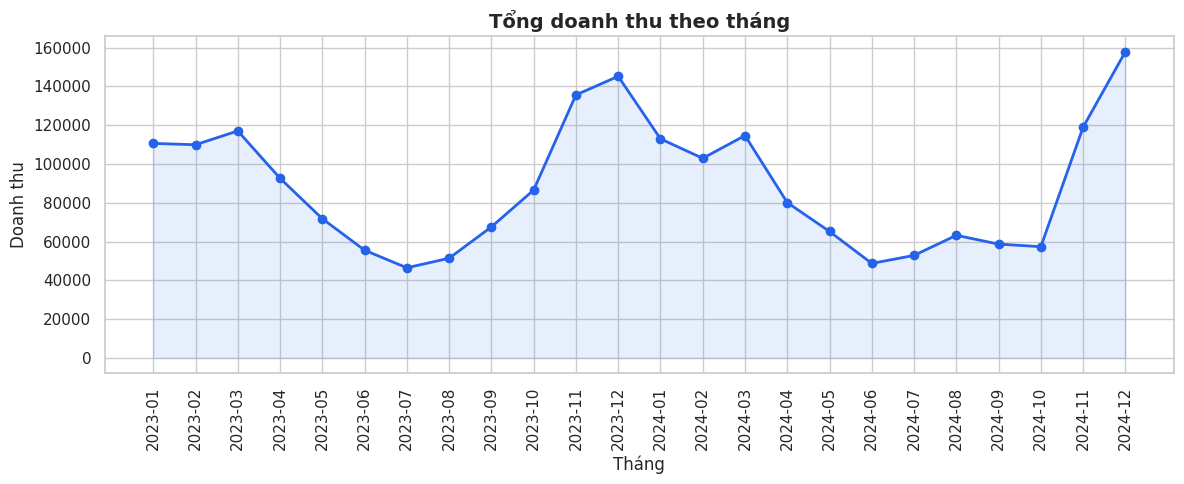

In [4]:
monthly = df.groupby("Month")["Sales_Amount"].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly["Month"], monthly["Sales_Amount"], marker="o", color="#2563eb", linewidth=2)
ax.set_title("Tổng doanh thu theo tháng", fontsize=14, fontweight="bold")
ax.set_xlabel("Tháng")
ax.set_ylabel("Doanh thu")
ax.tick_params(axis="x", rotation=90)
ax.fill_between(monthly["Month"], monthly["Sales_Amount"], alpha=0.1, color="#2563eb")
plt.tight_layout()
plt.show()

### 3.2 Bar chart (đứng & ngang) — Doanh thu theo danh mục

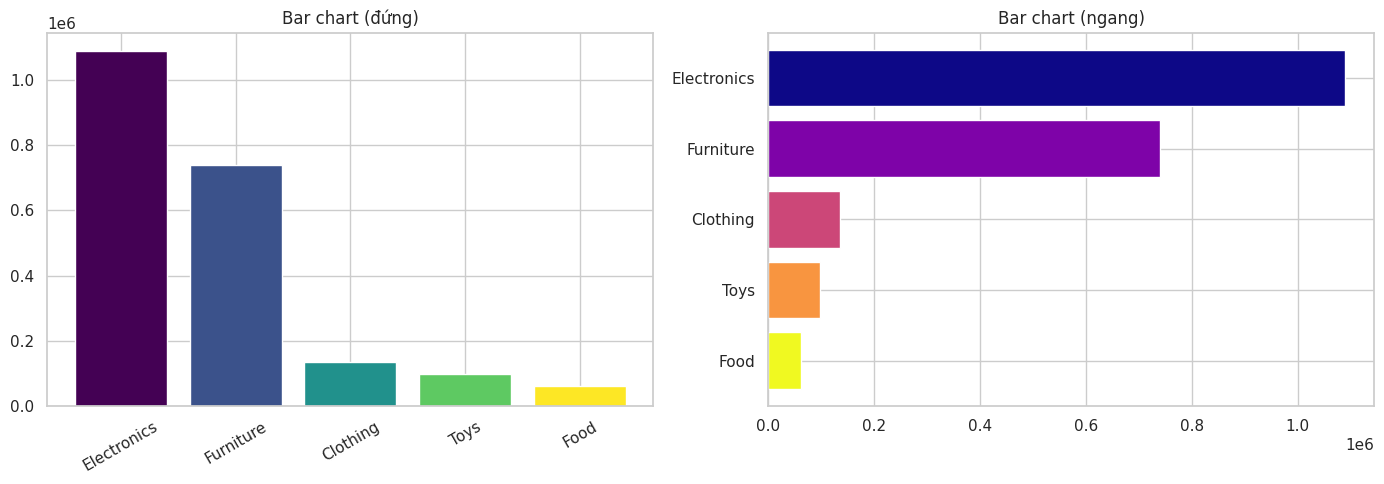

In [5]:
cat_sales = df.groupby("Category")["Sales_Amount"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(cat_sales.index, cat_sales.values, color=plt.cm.viridis(np.linspace(0, 1, len(cat_sales))))
axes[0].set_title("Bar chart (đứng)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].barh(cat_sales.index, cat_sales.values, color=plt.cm.plasma(np.linspace(0, 1, len(cat_sales))))
axes[1].set_title("Bar chart (ngang)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 3.3 Grouped & Stacked bar chart — Doanh thu theo Region x Channel

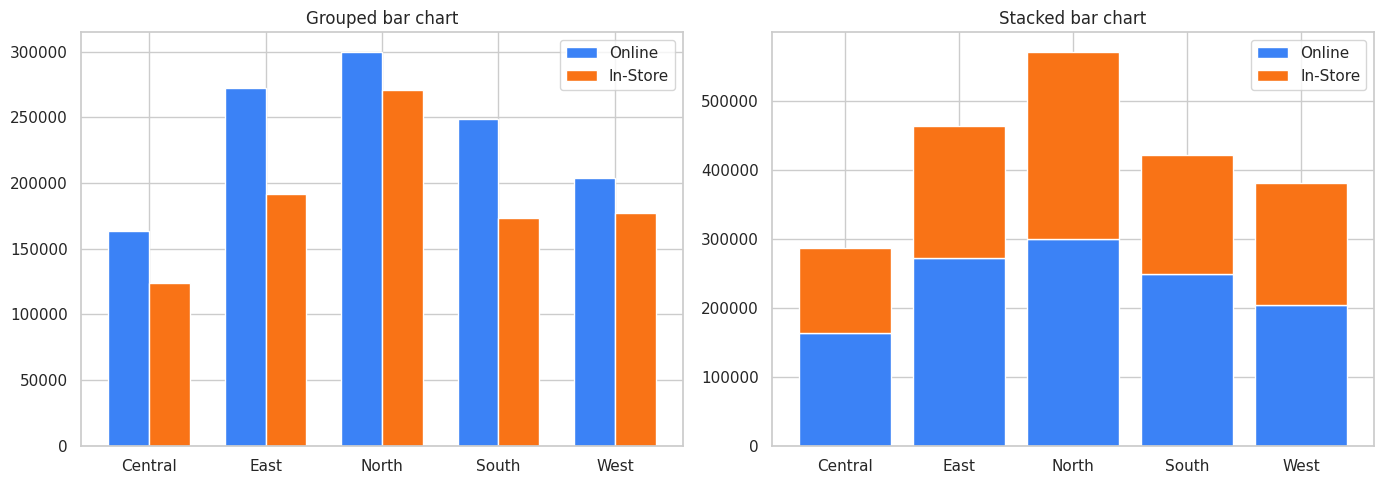

In [6]:
pivot = df.pivot_table(index="Region", columns="Channel", values="Sales_Amount", aggfunc="sum")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(pivot.index))
width = 0.35
axes[0].bar(x - width/2, pivot["Online"], width, label="Online", color="#3b82f6")
axes[0].bar(x + width/2, pivot["In-Store"], width, label="In-Store", color="#f97316")
axes[0].set_xticks(x)
axes[0].set_xticklabels(pivot.index)
axes[0].set_title("Grouped bar chart")
axes[0].legend()

axes[1].bar(pivot.index, pivot["Online"], label="Online", color="#3b82f6")
axes[1].bar(pivot.index, pivot["In-Store"], bottom=pivot["Online"], label="In-Store", color="#f97316")
axes[1].set_title("Stacked bar chart")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Scatter plot — Đơn giá vs Doanh thu

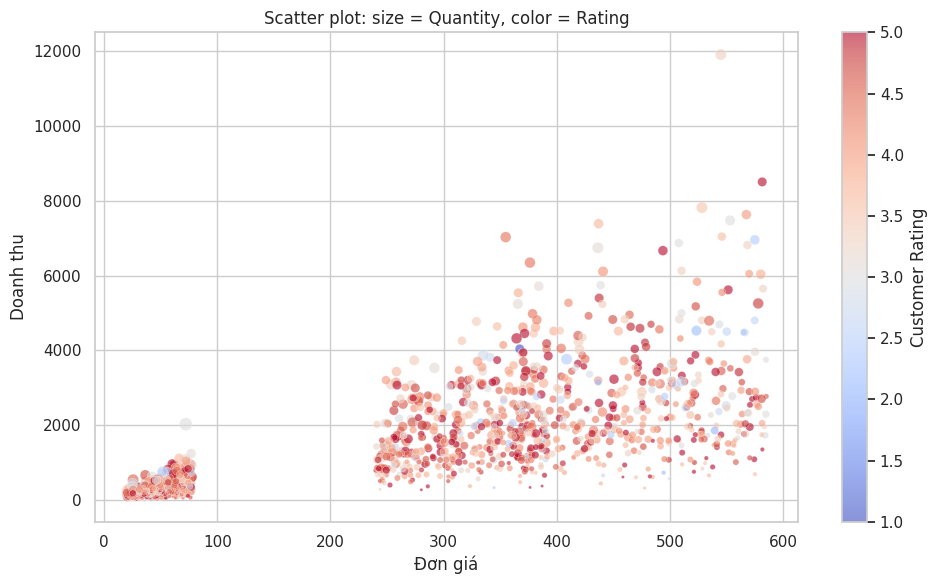

In [7]:
fig, ax = plt.subplots()
scatter = ax.scatter(
    df["Unit_Price"], df["Sales_Amount"],
    c=df["Customer_Rating"], cmap="coolwarm",
    alpha=0.6, s=df["Quantity"]*5, edgecolors="white", linewidths=0.3
)
ax.set_xlabel("Đơn giá")
ax.set_ylabel("Doanh thu")
ax.set_title("Scatter plot: size = Quantity, color = Rating")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Customer Rating")
plt.tight_layout()
plt.show()

### 3.5 Histogram — Phân phối tuổi khách hàng

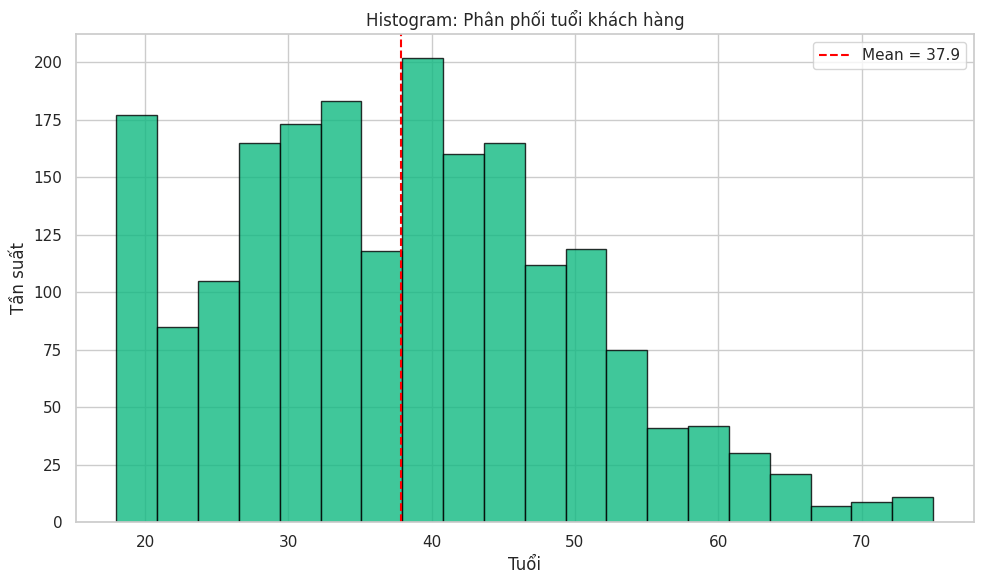

In [8]:
fig, ax = plt.subplots()
ax.hist(df["Customer_Age"], bins=20, color="#10b981", edgecolor="black", alpha=0.8)
ax.axvline(df["Customer_Age"].mean(), color="red", linestyle="--", label=f'Mean = {df["Customer_Age"].mean():.1f}')
ax.set_title("Histogram: Phân phối tuổi khách hàng")
ax.set_xlabel("Tuổi")
ax.set_ylabel("Tần suất")
ax.legend()
plt.tight_layout()
plt.show()

### 3.6 Pie chart & Donut chart — Tỉ trọng theo phương thức thanh toán

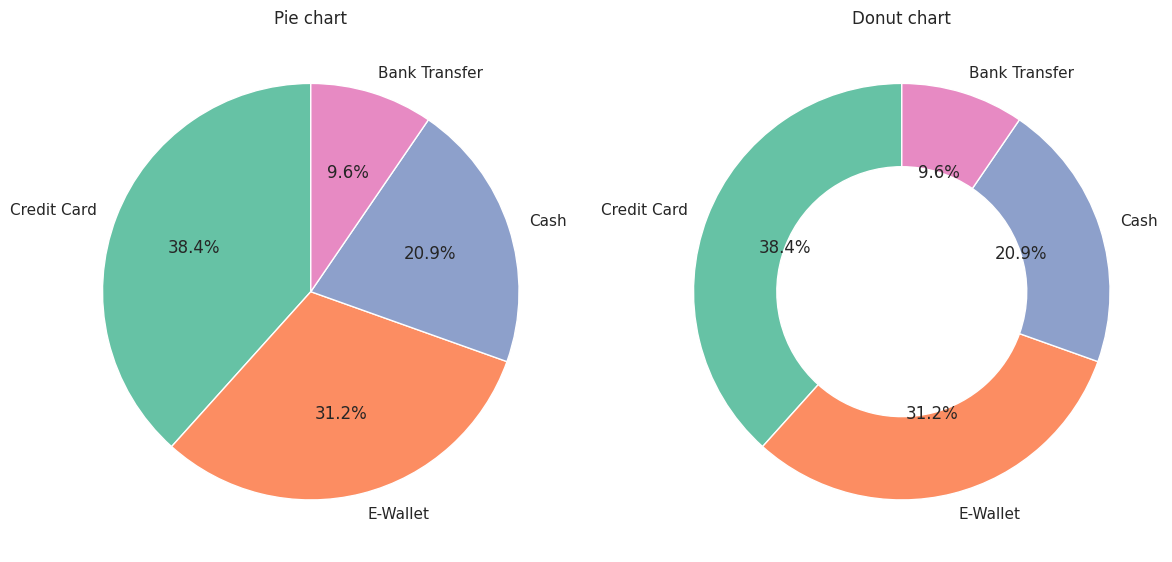

In [9]:
pay = df["Payment_Method"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(pay.values, labels=pay.index, autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("Set2", len(pay)))
axes[0].set_title("Pie chart")

axes[1].pie(pay.values, labels=pay.index, autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("Set2", len(pay)), wedgeprops=dict(width=0.4))
axes[1].set_title("Donut chart")

plt.tight_layout()
plt.show()

### 3.7 Boxplot (matplotlib thuần)

/tmp/ipykernel_474/3970297767.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cat, labels=cats, patch_artist=True, showmeans=True)


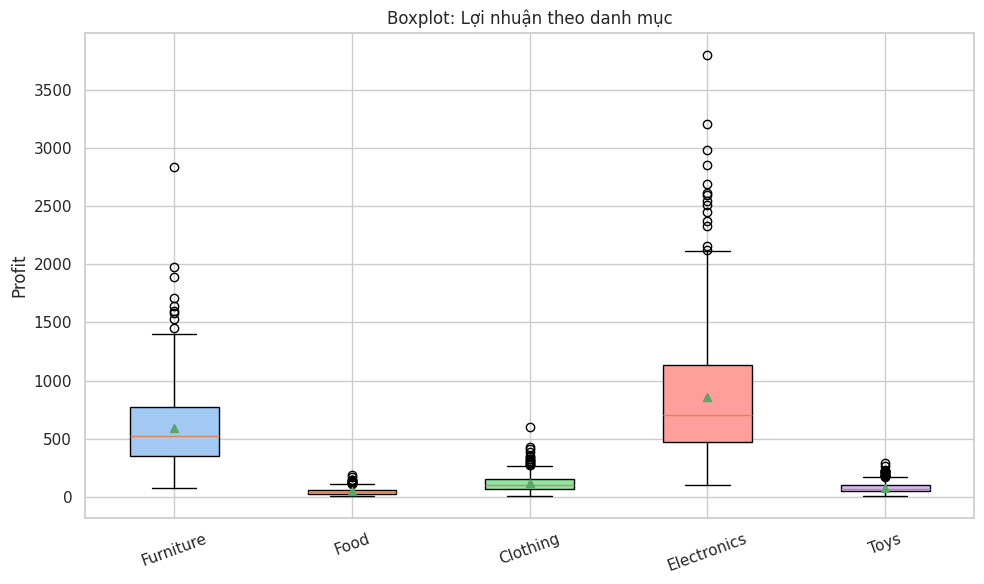

In [10]:
cats = df["Category"].unique()
data_by_cat = [df.loc[df["Category"] == c, "Profit"] for c in cats]

fig, ax = plt.subplots()
bp = ax.boxplot(data_by_cat, labels=cats, patch_artist=True, showmeans=True)
for patch, color in zip(bp["boxes"], sns.color_palette("pastel", len(cats))):
    patch.set_facecolor(color)
ax.set_title("Boxplot: Lợi nhuận theo danh mục")
ax.set_ylabel("Profit")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### 3.8 Area chart / Stackplot — Doanh thu theo danh mục theo thời gian

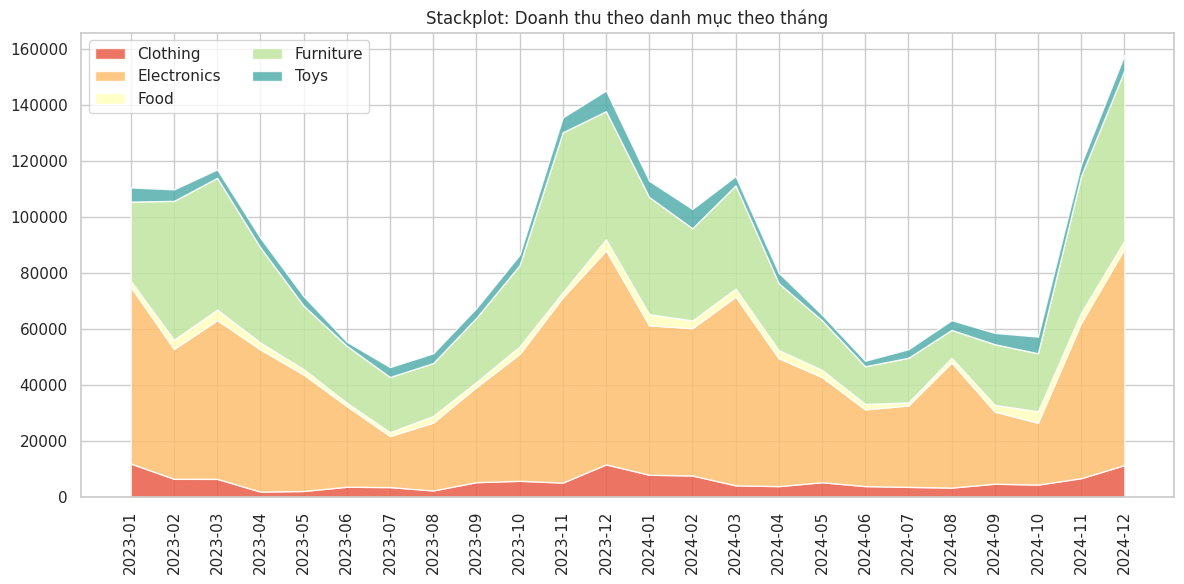

In [11]:
area_data = df.pivot_table(index="Month", columns="Category", values="Sales_Amount", aggfunc="sum").fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(area_data.index, area_data.values.T, labels=area_data.columns,
             colors=sns.color_palette("Spectral", area_data.shape[1]), alpha=0.85)
ax.set_title("Stackplot: Doanh thu theo danh mục theo tháng")
ax.legend(loc="upper left", ncol=2)
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

### 3.9 Heatmap thuần Matplotlib (imshow) — Ma trận tương quan

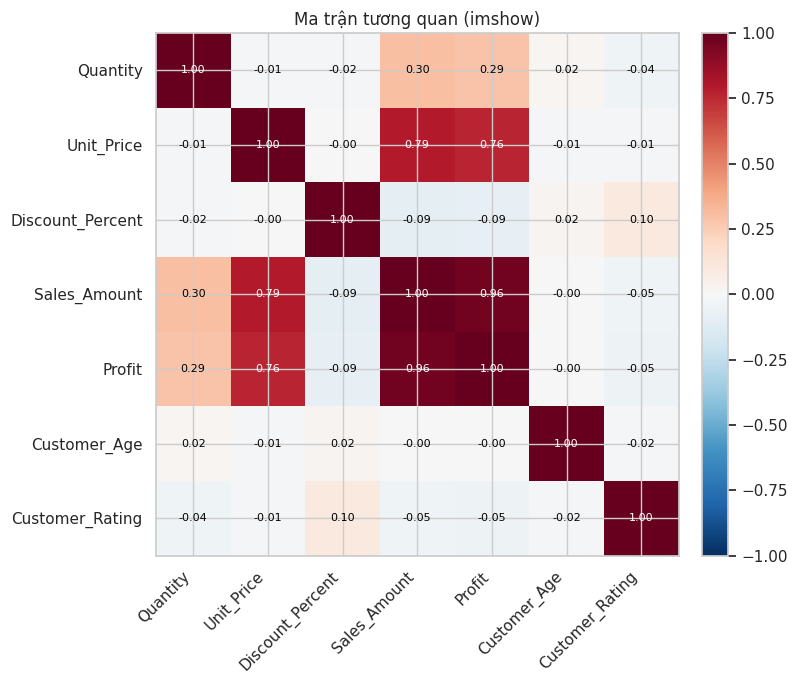

In [12]:
numeric_cols = ["Quantity", "Unit_Price", "Discount_Percent", "Sales_Amount", "Profit", "Customer_Age", "Customer_Rating"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black", fontsize=8)
ax.set_title("Ma trận tương quan (imshow)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### 3.10 Error bar plot — Doanh thu trung bình ± độ lệch chuẩn theo khu vực

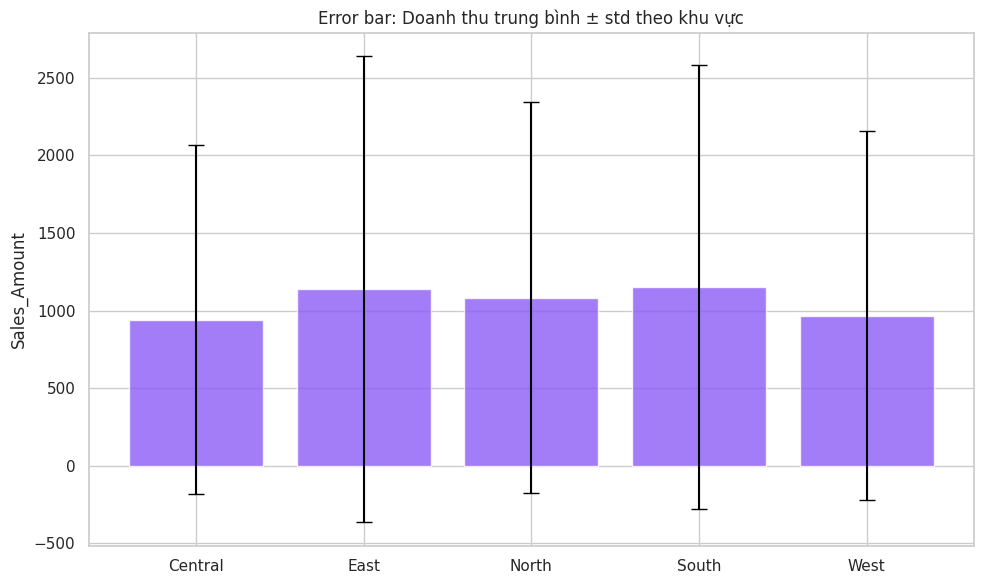

In [13]:
region_stats = df.groupby("Region")["Sales_Amount"].agg(["mean", "std"])

fig, ax = plt.subplots()
ax.bar(region_stats.index, region_stats["mean"], yerr=region_stats["std"],
       capsize=6, color="#8b5cf6", alpha=0.8, ecolor="black")
ax.set_title("Error bar: Doanh thu trung bình ± std theo khu vực")
ax.set_ylabel("Sales_Amount")
plt.tight_layout()
plt.show()

### 3.11 Twin axes (2 trục Y) — Doanh thu vs Lợi nhuận theo tháng

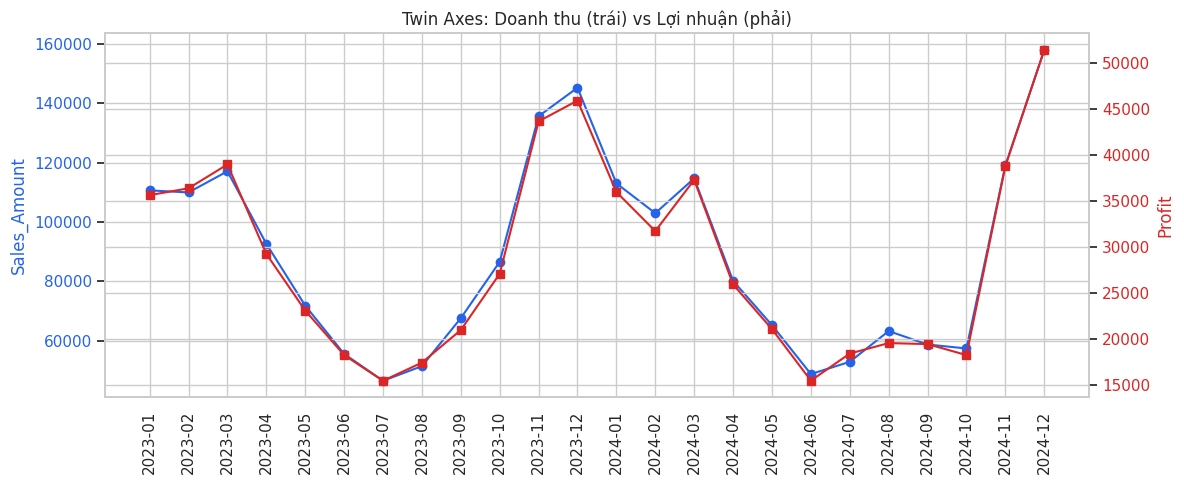

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly["Month"], monthly["Sales_Amount"], color="#2563eb", marker="o", label="Sales")
ax1.set_ylabel("Sales_Amount", color="#2563eb")
ax1.tick_params(axis="y", labelcolor="#2563eb")
ax1.tick_params(axis="x", rotation=90)

profit_monthly = df.groupby("Month")["Profit"].sum()
ax2 = ax1.twinx()
ax2.plot(monthly["Month"], profit_monthly.values, color="#dc2626", marker="s", label="Profit")
ax2.set_ylabel("Profit", color="#dc2626")
ax2.tick_params(axis="y", labelcolor="#dc2626")

ax1.set_title("Twin Axes: Doanh thu (trái) vs Lợi nhuận (phải)")
plt.tight_layout()
plt.show()

### 3.12 Subplots lưới (GridSpec) — Dashboard tổng hợp

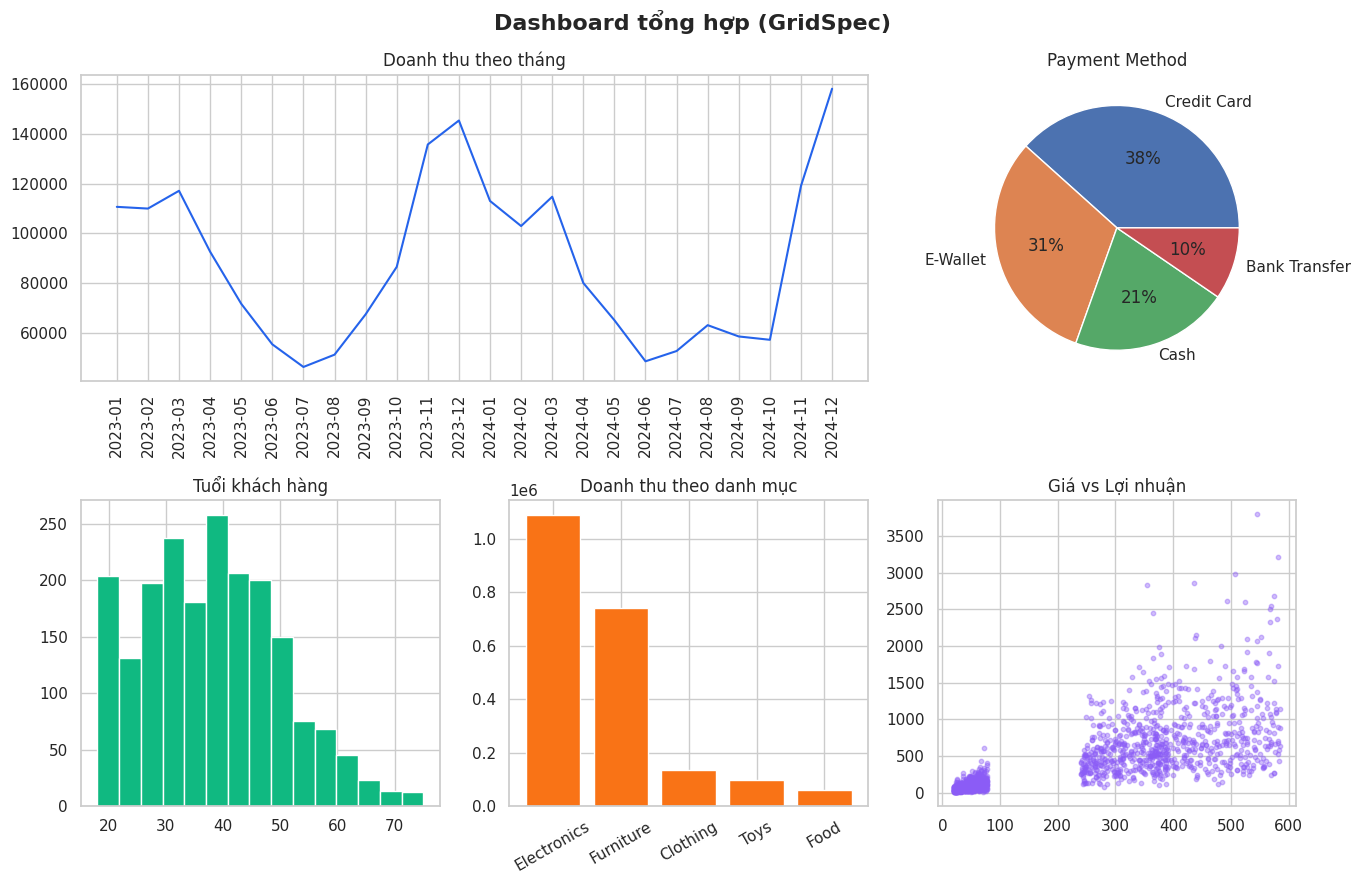

In [15]:
fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(monthly["Month"], monthly["Sales_Amount"], color="#2563eb")
ax1.set_title("Doanh thu theo tháng")
ax1.tick_params(axis="x", rotation=90)

ax2 = fig.add_subplot(gs[0, 2])
ax2.pie(pay.values, labels=pay.index, autopct="%1.0f%%")
ax2.set_title("Payment Method")

ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(df["Customer_Age"], bins=15, color="#10b981")
ax3.set_title("Tuổi khách hàng")

ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(cat_sales.index, cat_sales.values, color="#f97316")
ax4.tick_params(axis="x", rotation=30)
ax4.set_title("Doanh thu theo danh mục")

ax5 = fig.add_subplot(gs[1, 2])
ax5.scatter(df["Unit_Price"], df["Profit"], alpha=0.4, s=10, color="#8b5cf6")
ax5.set_title("Giá vs Lợi nhuận")

fig.suptitle("Dashboard tổng hợp (GridSpec)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.13 Biểu đồ 3D (mplot3d)

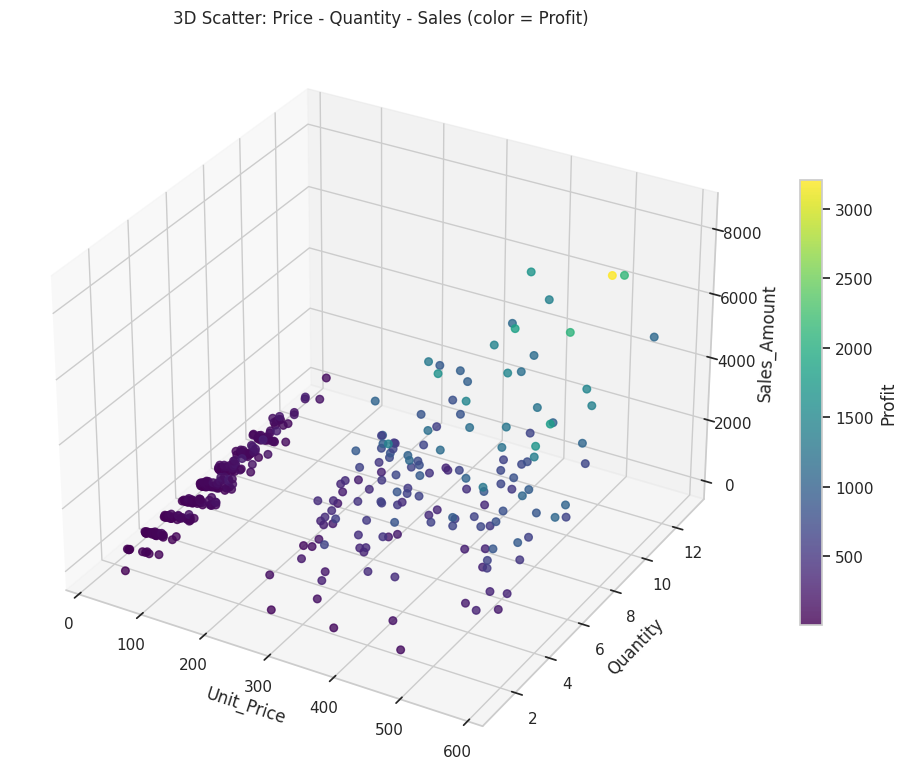

In [16]:
from mpl_toolkits.mplot3d import Axes3D

sample = df.sample(400, random_state=1)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(sample["Unit_Price"], sample["Quantity"], sample["Sales_Amount"],
               c=sample["Profit"], cmap="viridis", s=30, alpha=0.8)
ax.set_xlabel("Unit_Price")
ax.set_ylabel("Quantity")
ax.set_zlabel("Sales_Amount")
ax.set_title("3D Scatter: Price - Quantity - Sales (color = Profit)")
fig.colorbar(p, ax=ax, shrink=0.6, label="Profit")
plt.tight_layout()
plt.show()

## 4. Seaborn — Relational plots

### 4.1 `sns.scatterplot`

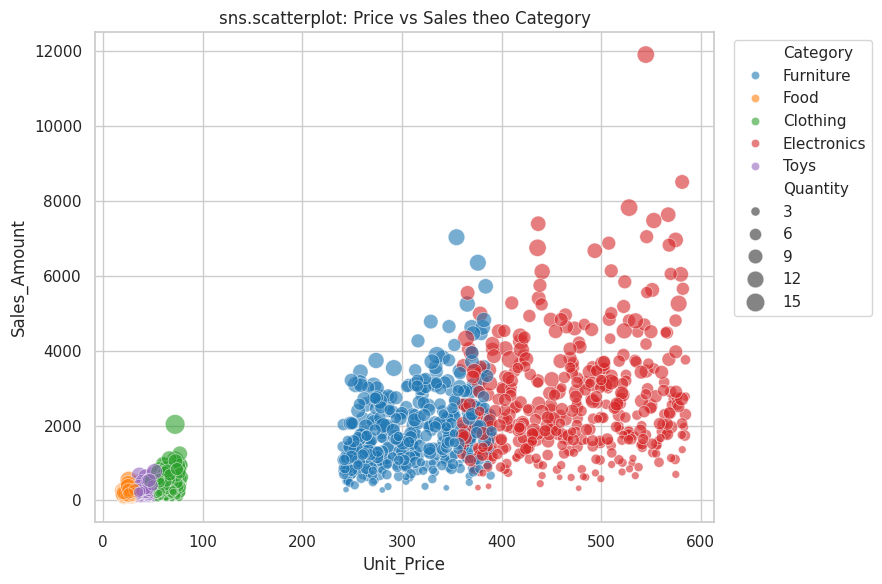

In [17]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Unit_Price", y="Sales_Amount", hue="Category", size="Quantity",
                 alpha=0.6, palette="tab10", sizes=(20, 200))
plt.title("sns.scatterplot: Price vs Sales theo Category")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 4.2 `sns.lineplot` (với khoảng tin cậy)

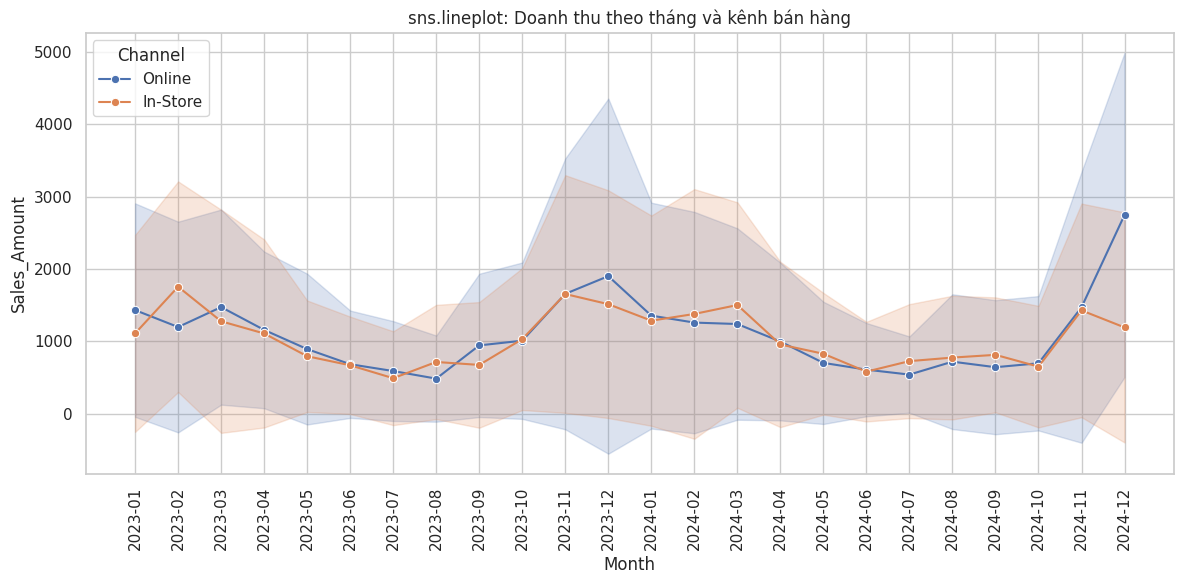

In [18]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Month", y="Sales_Amount", hue="Channel", marker="o", errorbar="sd")
plt.xticks(rotation=90)
plt.title("sns.lineplot: Doanh thu theo tháng và kênh bán hàng")
plt.tight_layout()
plt.show()

### 4.3 `sns.relplot` (Facet theo Category)

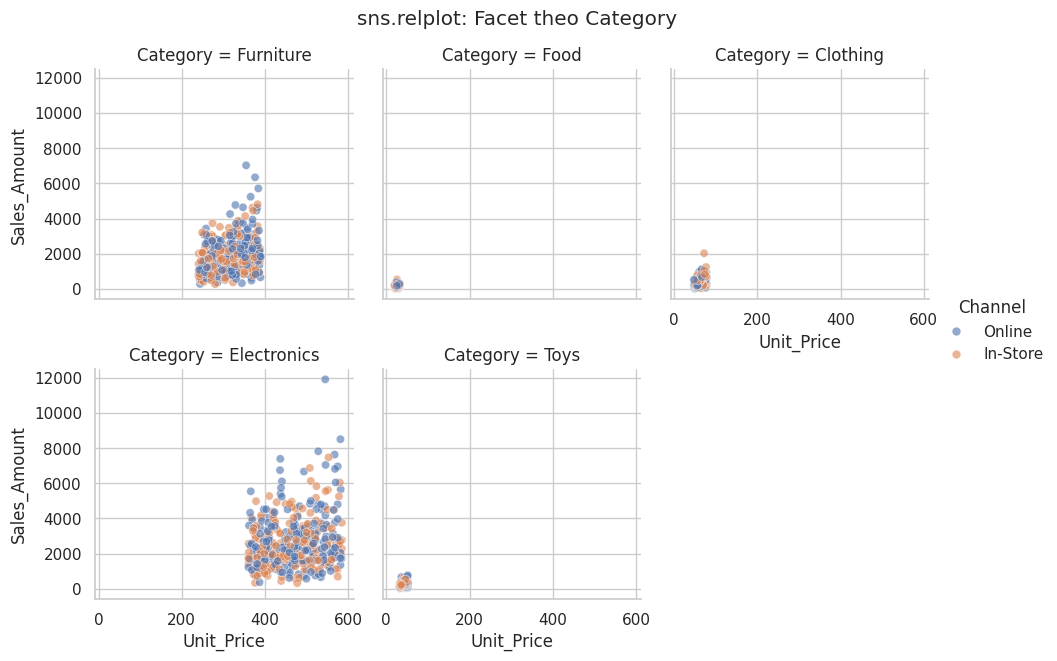

In [19]:
g = sns.relplot(
    data=df, x="Unit_Price", y="Sales_Amount", hue="Channel", col="Category",
    col_wrap=3, kind="scatter", height=3.2, alpha=0.6
)
g.fig.suptitle("sns.relplot: Facet theo Category", y=1.03)
plt.show()

## 5. Seaborn — Distribution plots

### 5.1 `sns.histplot`

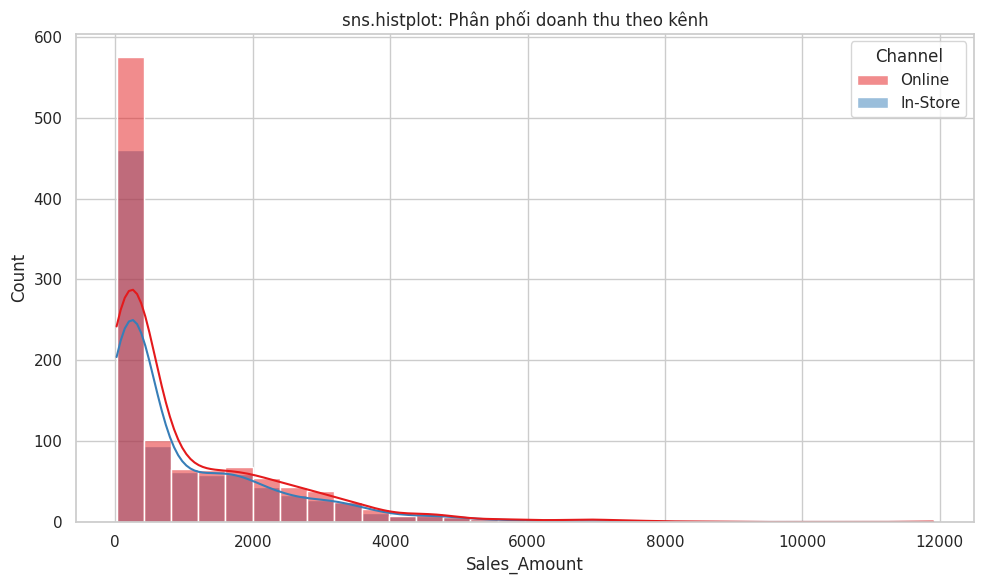

In [20]:
plt.figure()
sns.histplot(data=df, x="Sales_Amount", hue="Channel", kde=True, bins=30, palette="Set1", alpha=0.5)
plt.title("sns.histplot: Phân phối doanh thu theo kênh")
plt.tight_layout()
plt.show()

### 5.2 `sns.kdeplot`

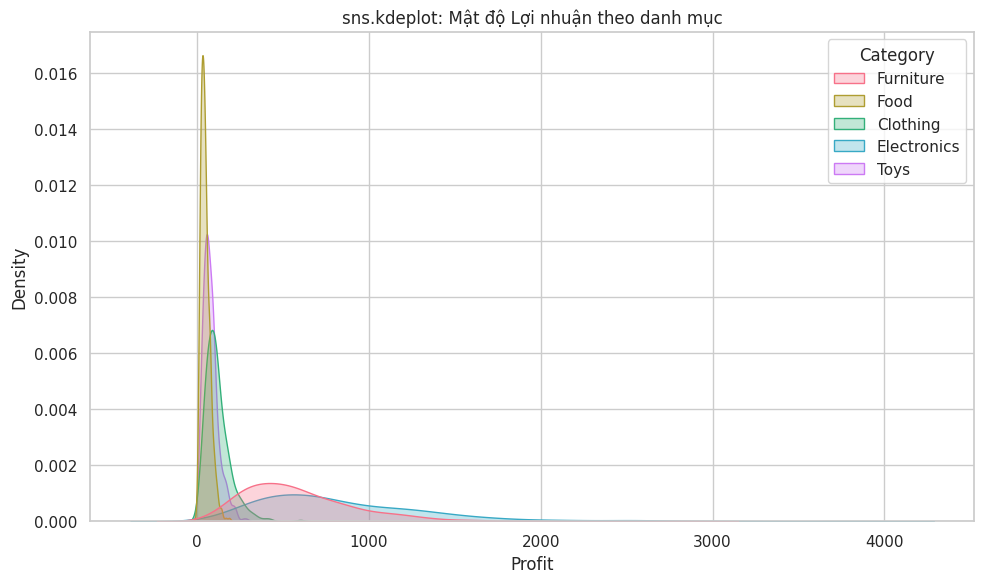

In [21]:
plt.figure()
sns.kdeplot(data=df, x="Profit", hue="Category", fill=True, common_norm=False, alpha=0.3, palette="husl")
plt.title("sns.kdeplot: Mật độ Lợi nhuận theo danh mục")
plt.tight_layout()
plt.show()

### 5.3 `sns.ecdfplot`

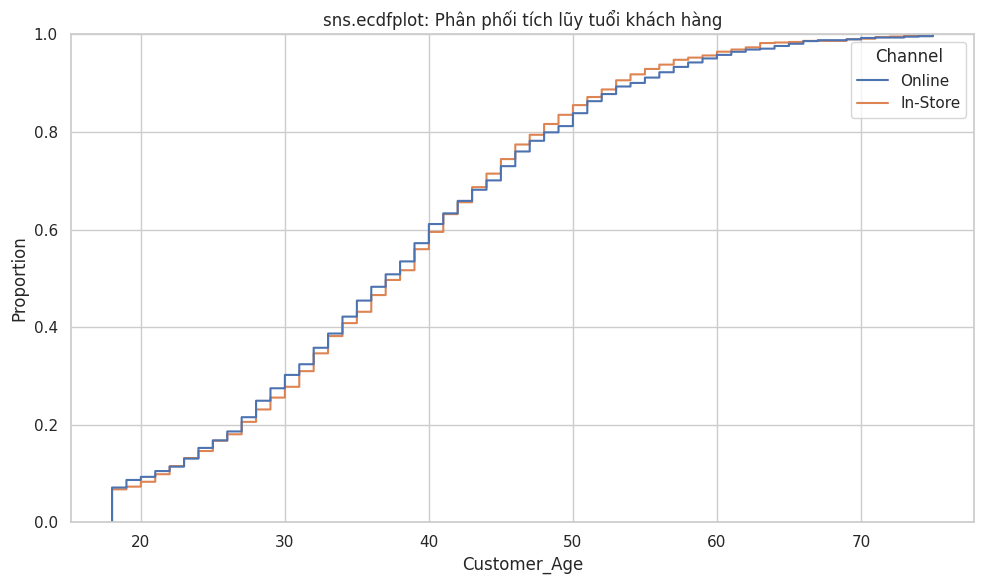

In [22]:
plt.figure()
sns.ecdfplot(data=df, x="Customer_Age", hue="Channel")
plt.title("sns.ecdfplot: Phân phối tích lũy tuổi khách hàng")
plt.tight_layout()
plt.show()

### 5.4 `sns.rugplot` kết hợp `histplot`

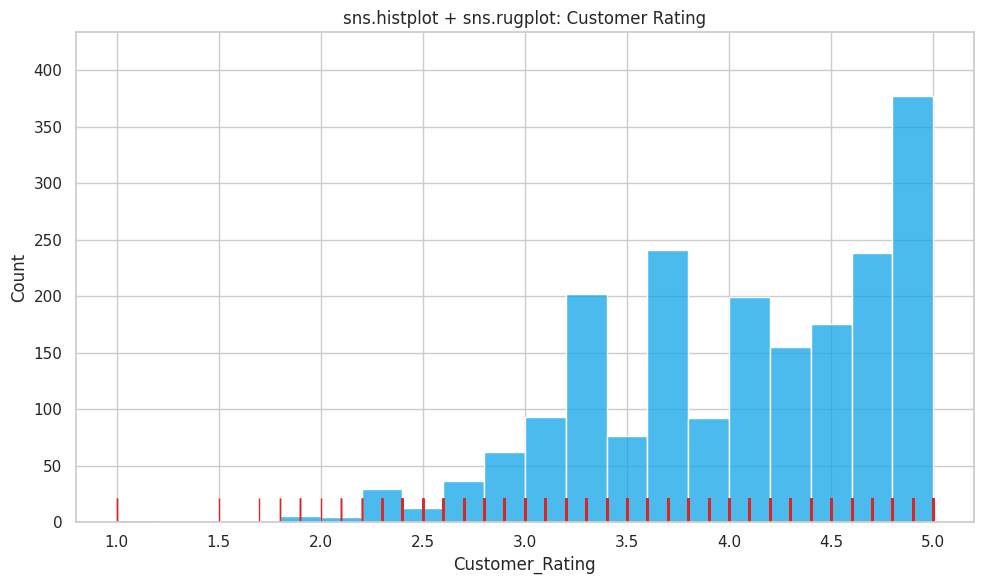

In [23]:
plt.figure()
sns.histplot(data=df, x="Customer_Rating", bins=20, color="#0ea5e9")
sns.rugplot(data=df, x="Customer_Rating", color="#dc2626", height=0.05)
plt.title("sns.histplot + sns.rugplot: Customer Rating")
plt.tight_layout()
plt.show()

### 5.5 `sns.displot` (figure-level, nhiều facet)

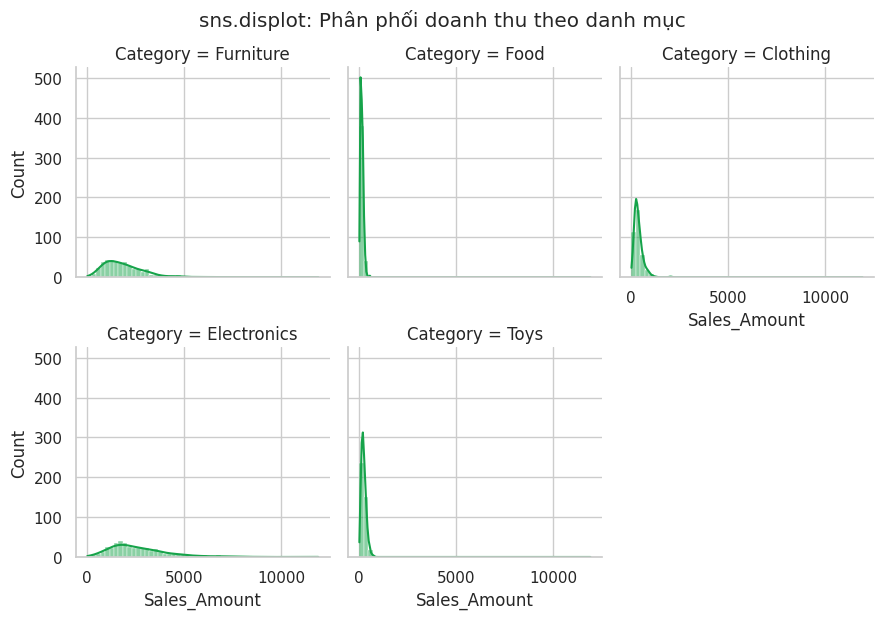

In [24]:
g = sns.displot(data=df, x="Sales_Amount", col="Category", kind="hist", kde=True,
                 col_wrap=3, height=3, color="#16a34a")
g.fig.suptitle("sns.displot: Phân phối doanh thu theo danh mục", y=1.03)
plt.show()

## 6. Seaborn — Categorical plots

### 6.1 `sns.barplot`

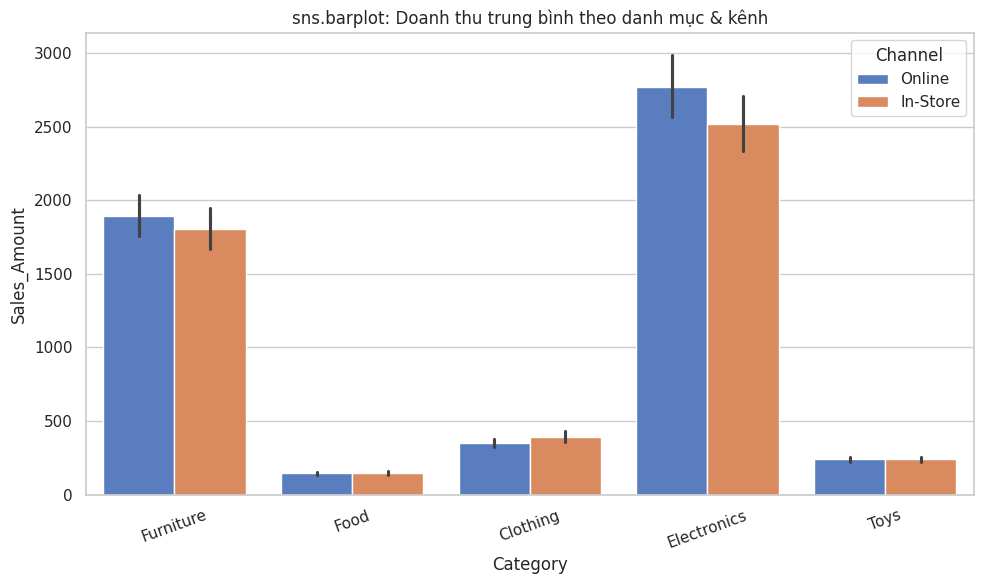

In [25]:
plt.figure()
sns.barplot(data=df, x="Category", y="Sales_Amount", hue="Channel", estimator=np.mean, errorbar="ci", palette="muted")
plt.xticks(rotation=20)
plt.title("sns.barplot: Doanh thu trung bình theo danh mục & kênh")
plt.tight_layout()
plt.show()

### 6.2 `sns.countplot`

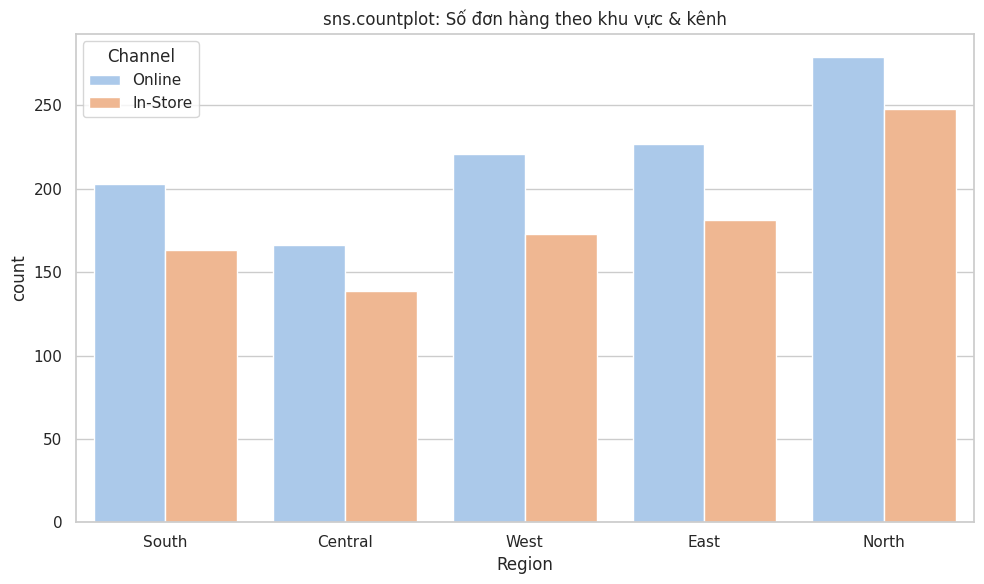

In [26]:
plt.figure()
sns.countplot(data=df, x="Region", hue="Channel", palette="pastel")
plt.title("sns.countplot: Số đơn hàng theo khu vực & kênh")
plt.tight_layout()
plt.show()

### 6.3 `sns.boxplot`

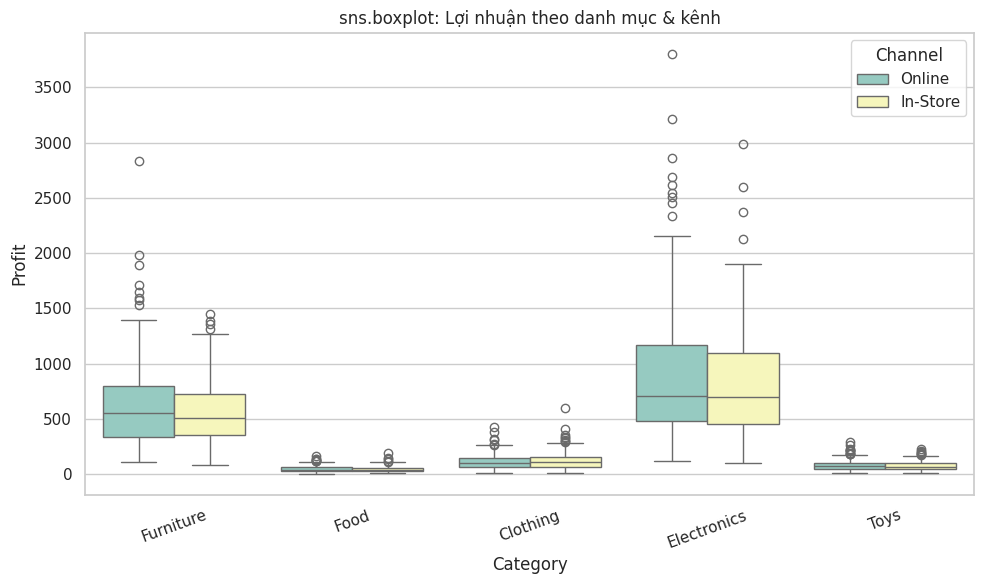

In [27]:
plt.figure()
sns.boxplot(data=df, x="Category", y="Profit", hue="Channel", palette="Set3")
plt.xticks(rotation=20)
plt.title("sns.boxplot: Lợi nhuận theo danh mục & kênh")
plt.tight_layout()
plt.show()

### 6.4 `sns.violinplot`

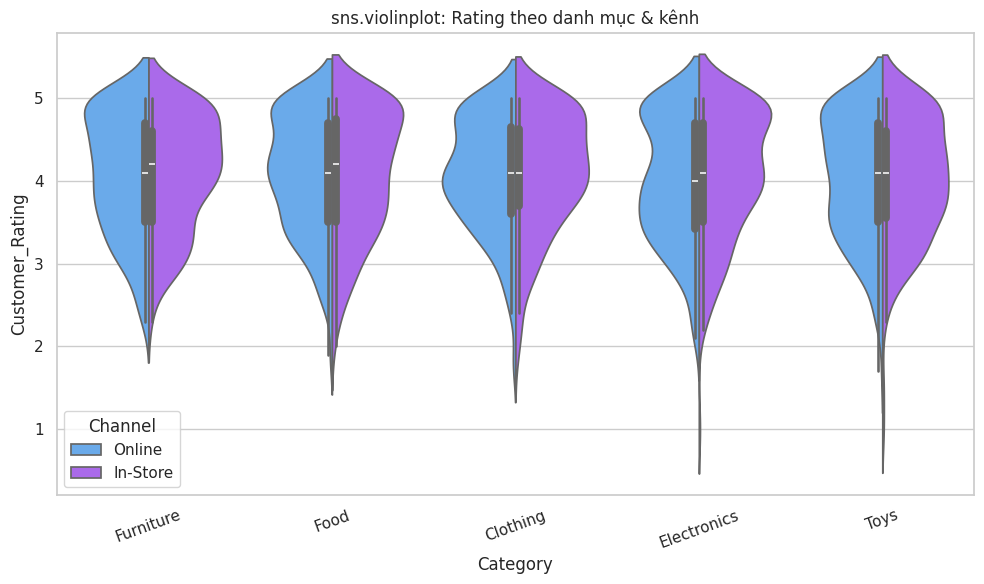

In [28]:
plt.figure()
sns.violinplot(data=df, x="Category", y="Customer_Rating", hue="Channel", split=True, palette="cool")
plt.xticks(rotation=20)
plt.title("sns.violinplot: Rating theo danh mục & kênh")
plt.tight_layout()
plt.show()

### 6.5 `sns.boxenplot`

/tmp/ipykernel_474/3567568637.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x="Region", y="Sales_Amount", palette="flare")


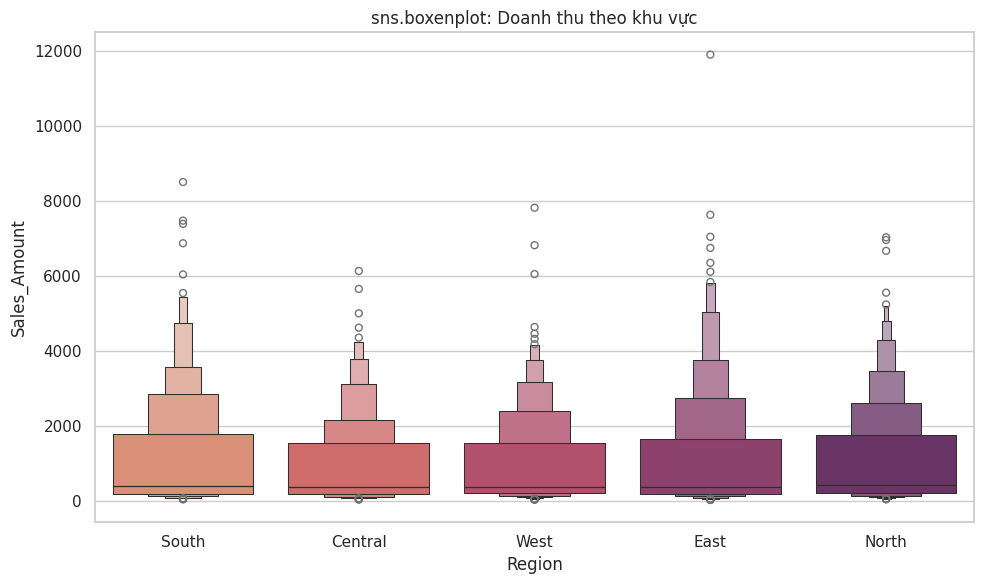

In [29]:
plt.figure()
sns.boxenplot(data=df, x="Region", y="Sales_Amount", palette="flare")
plt.title("sns.boxenplot: Doanh thu theo khu vực")
plt.tight_layout()
plt.show()

### 6.6 `sns.stripplot` & `sns.swarmplot`

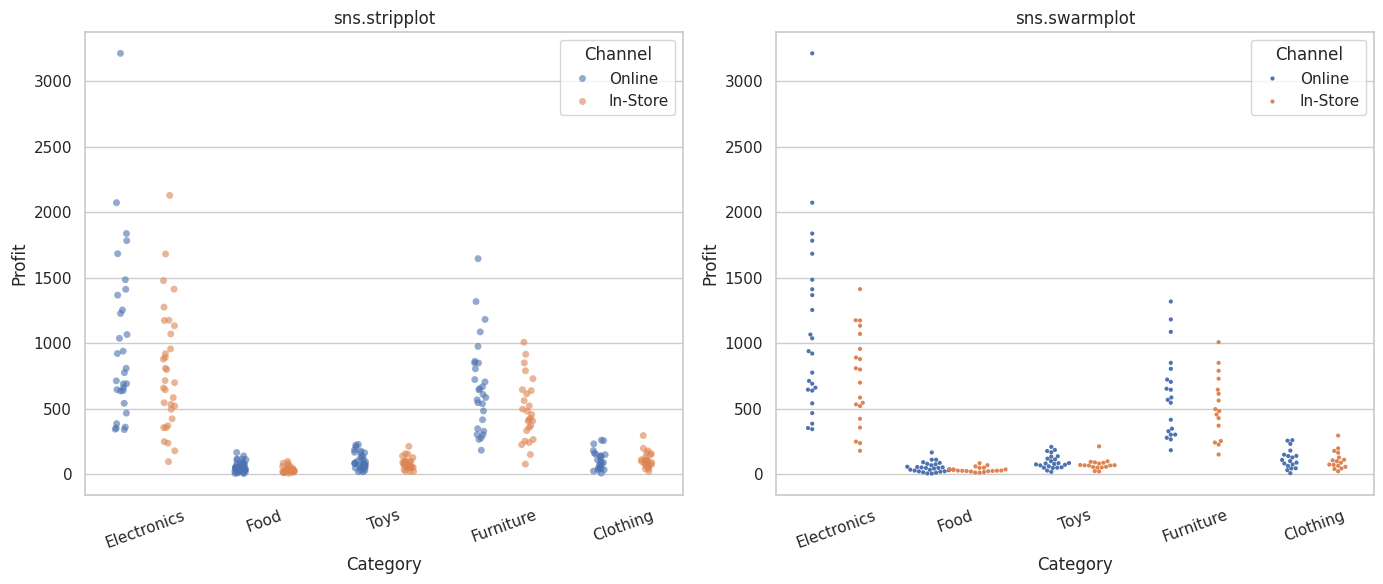

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.stripplot(data=df.sample(300, random_state=1), x="Category", y="Profit", hue="Channel",
              dodge=True, alpha=0.6, ax=axes[0])
axes[0].set_title("sns.stripplot")
axes[0].tick_params(axis="x", rotation=20)

sns.swarmplot(data=df.sample(200, random_state=1), x="Category", y="Profit", hue="Channel",
              dodge=True, size=3, ax=axes[1])
axes[1].set_title("sns.swarmplot")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### 6.7 `sns.pointplot`

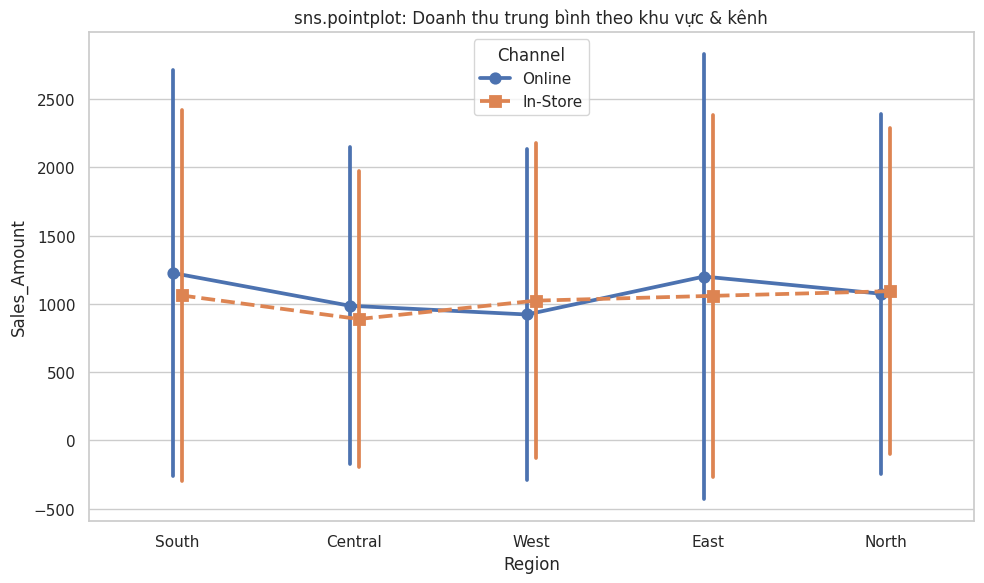

In [31]:
plt.figure()
sns.pointplot(data=df, x="Region", y="Sales_Amount", hue="Channel", dodge=True,
              errorbar="sd", markers=["o", "s"], linestyles=["-", "--"])
plt.title("sns.pointplot: Doanh thu trung bình theo khu vực & kênh")
plt.tight_layout()
plt.show()

### 6.8 `sns.catplot` (figure-level, nhiều loại kind)

/tmp/ipykernel_474/4075039404.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=df, x="Channel", y="Sales_Amount", col="Region", kind="box",


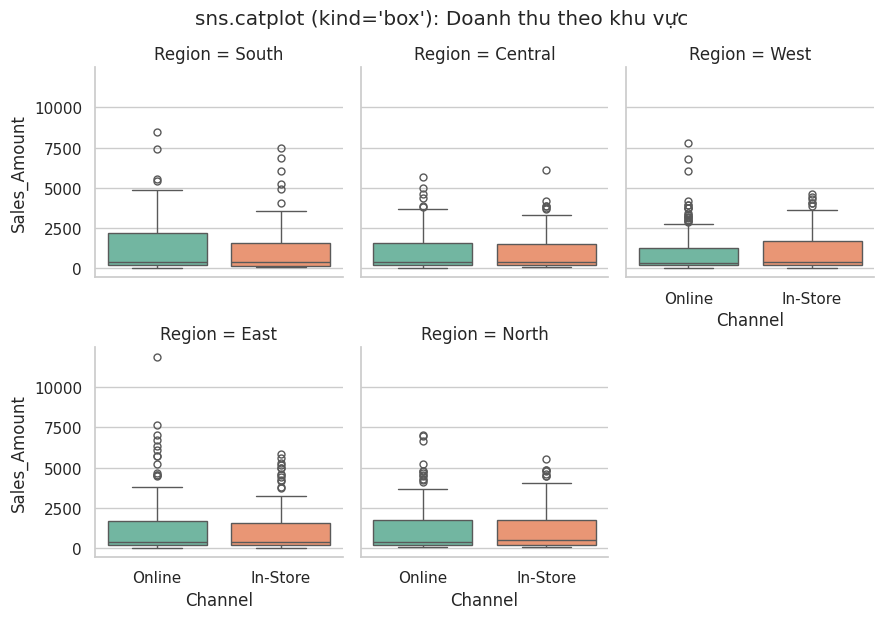

In [32]:
g = sns.catplot(data=df, x="Channel", y="Sales_Amount", col="Region", kind="box",
                 col_wrap=3, height=3, palette="Set2")
g.fig.suptitle("sns.catplot (kind='box'): Doanh thu theo khu vực", y=1.03)
plt.show()

## 7. Seaborn — Matrix, Regression & Multi-plot grids

### 7.1 `sns.heatmap` — Ma trận tương quan

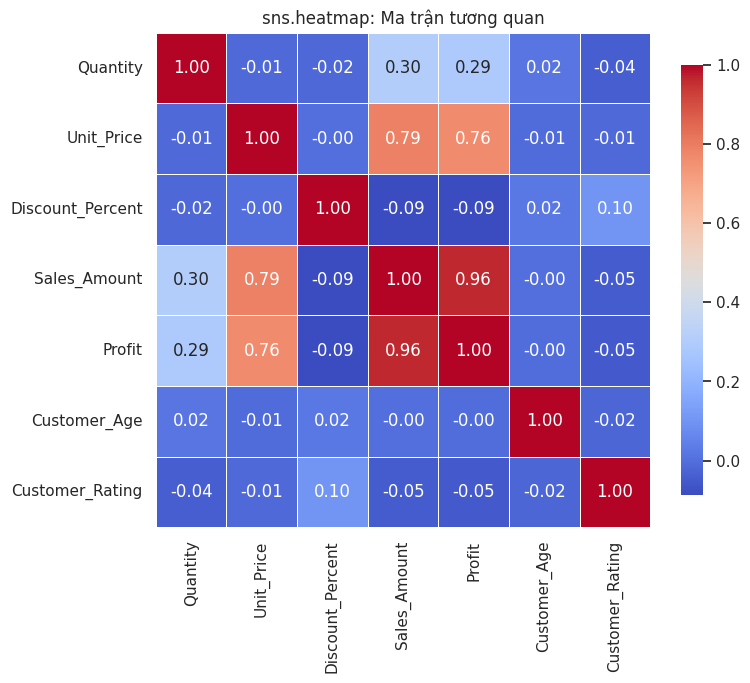

In [33]:
plt.figure(figsize=(8, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("sns.heatmap: Ma trận tương quan")
plt.tight_layout()
plt.show()

### 7.2 `sns.heatmap` — Bảng pivot doanh thu theo Region x Category

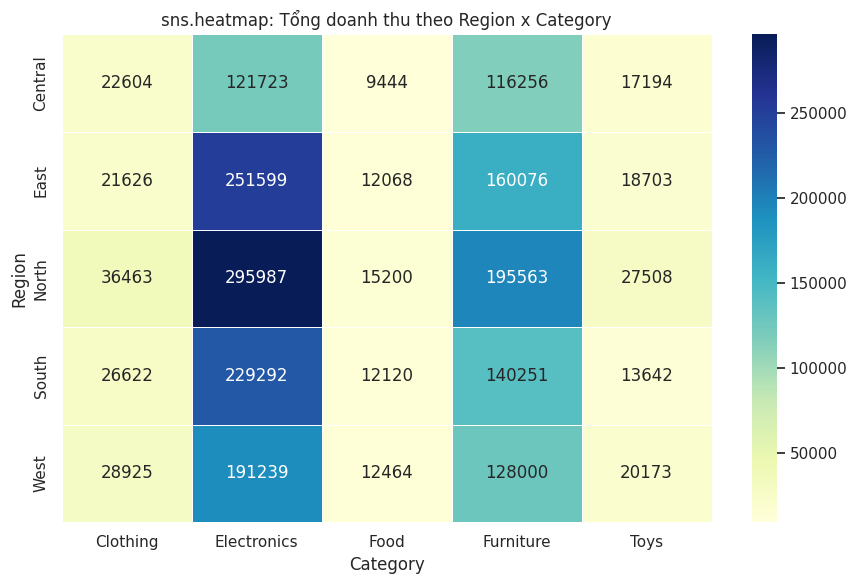

In [34]:
pivot2 = df.pivot_table(index="Region", columns="Category", values="Sales_Amount", aggfunc="sum")
plt.figure(figsize=(9, 6))
sns.heatmap(pivot2, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title("sns.heatmap: Tổng doanh thu theo Region x Category")
plt.tight_layout()
plt.show()

### 7.3 `sns.clustermap`

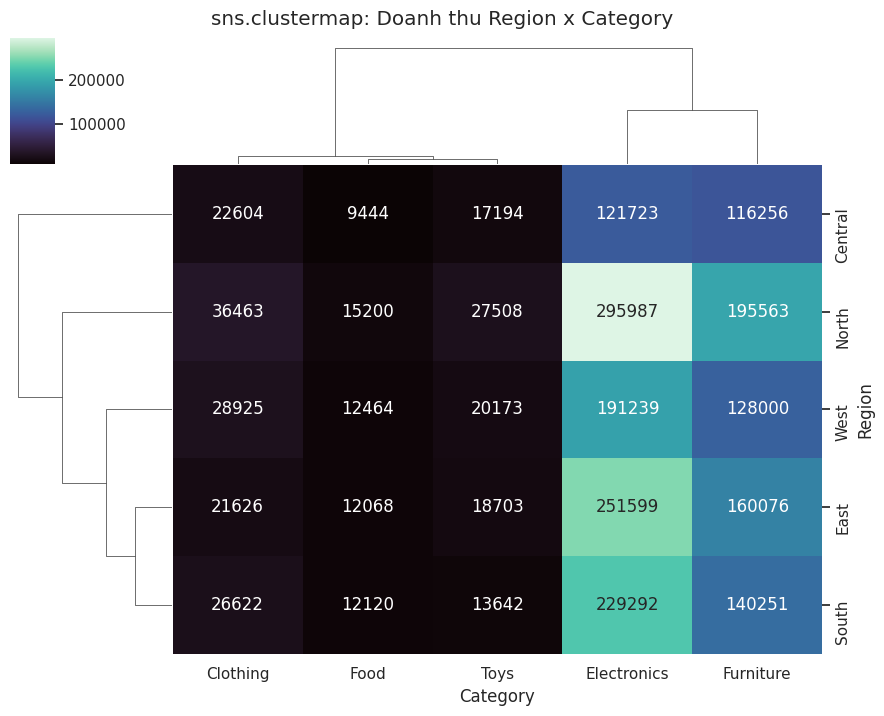

In [35]:
sns.clustermap(pivot2, cmap="mako", annot=True, fmt=".0f", figsize=(9, 7))
plt.suptitle("sns.clustermap: Doanh thu Region x Category", y=1.02)
plt.show()

### 7.4 `sns.regplot` & `sns.lmplot`

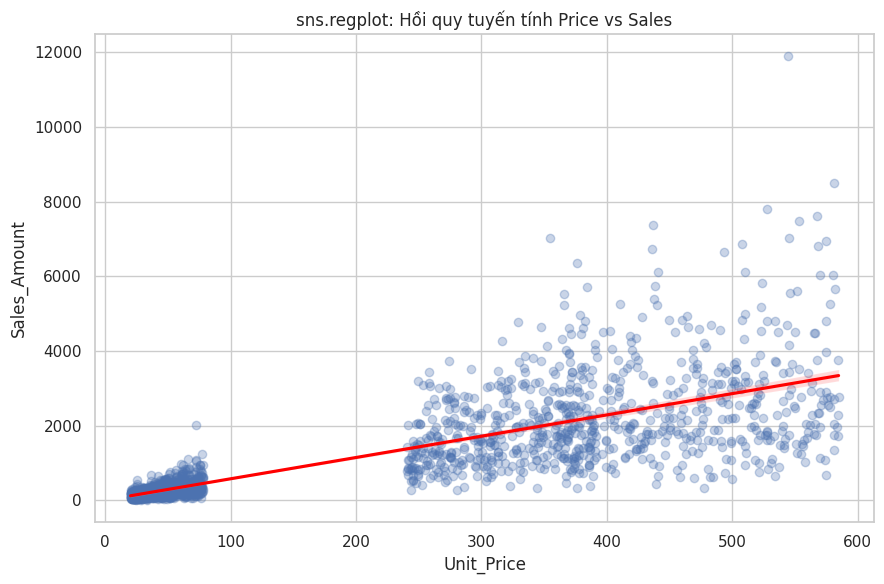

In [36]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=df, x="Unit_Price", y="Sales_Amount", scatter_kws={"alpha": 0.3}, line_kws={"color": "red"}, ax=ax)
ax.set_title("sns.regplot: Hồi quy tuyến tính Price vs Sales")
plt.tight_layout()
plt.show()

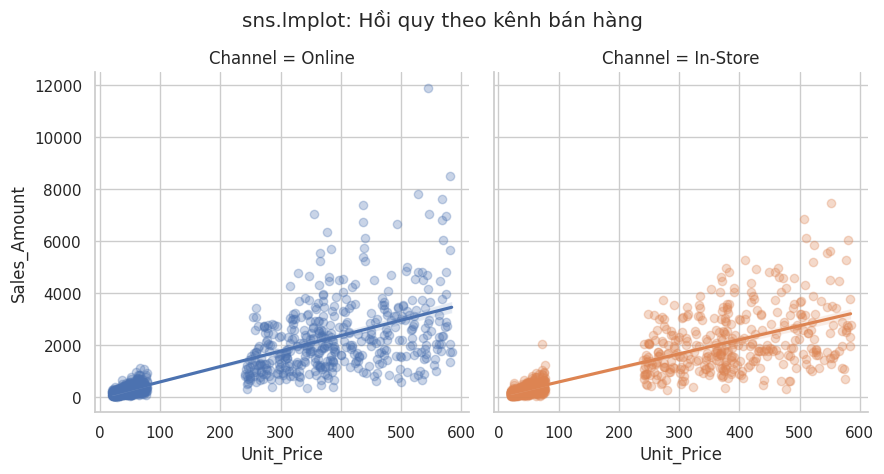

In [37]:
g = sns.lmplot(data=df, x="Unit_Price", y="Sales_Amount", hue="Channel", col="Channel",
                height=4.5, aspect=1, scatter_kws={"alpha": 0.3})
g.fig.suptitle("sns.lmplot: Hồi quy theo kênh bán hàng", y=1.05)
plt.show()

### 7.5 `sns.jointplot`

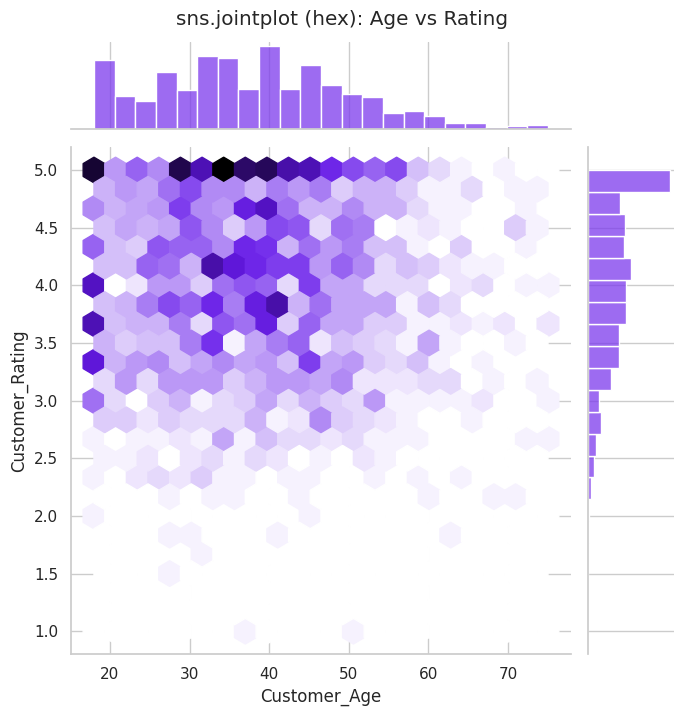

In [38]:
g = sns.jointplot(data=df, x="Customer_Age", y="Customer_Rating", kind="hex", height=7, color="#7c3aed")
g.fig.suptitle("sns.jointplot (hex): Age vs Rating", y=1.02)
plt.show()

### 7.6 `sns.pairplot`

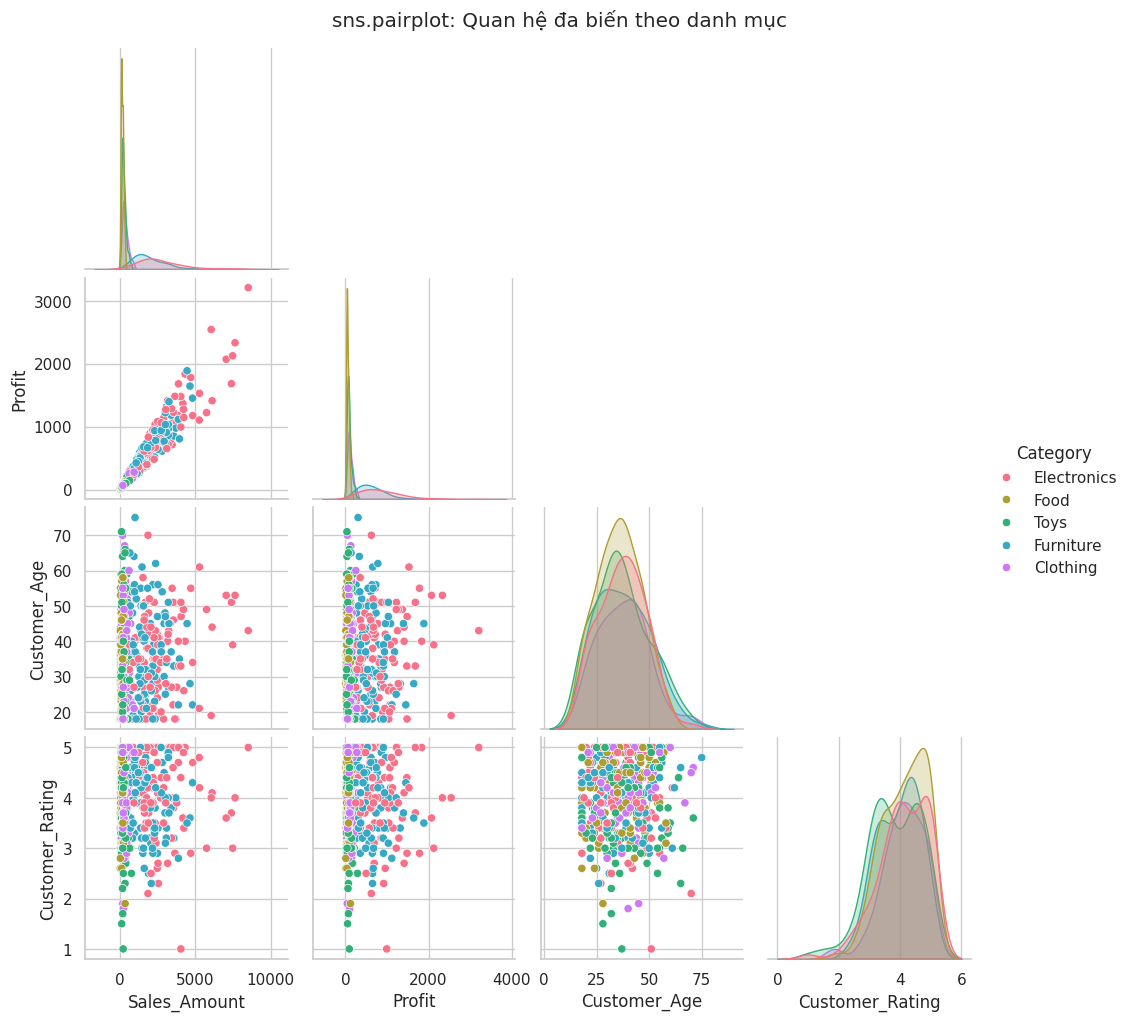

In [39]:
subset = df[["Sales_Amount", "Profit", "Customer_Age", "Customer_Rating", "Category"]].sample(500, random_state=1)
g = sns.pairplot(subset, hue="Category", diag_kind="kde", palette="husl", corner=True)
g.fig.suptitle("sns.pairplot: Quan hệ đa biến theo danh mục", y=1.02)
plt.show()

### 7.7 `sns.FacetGrid` tùy chỉnh

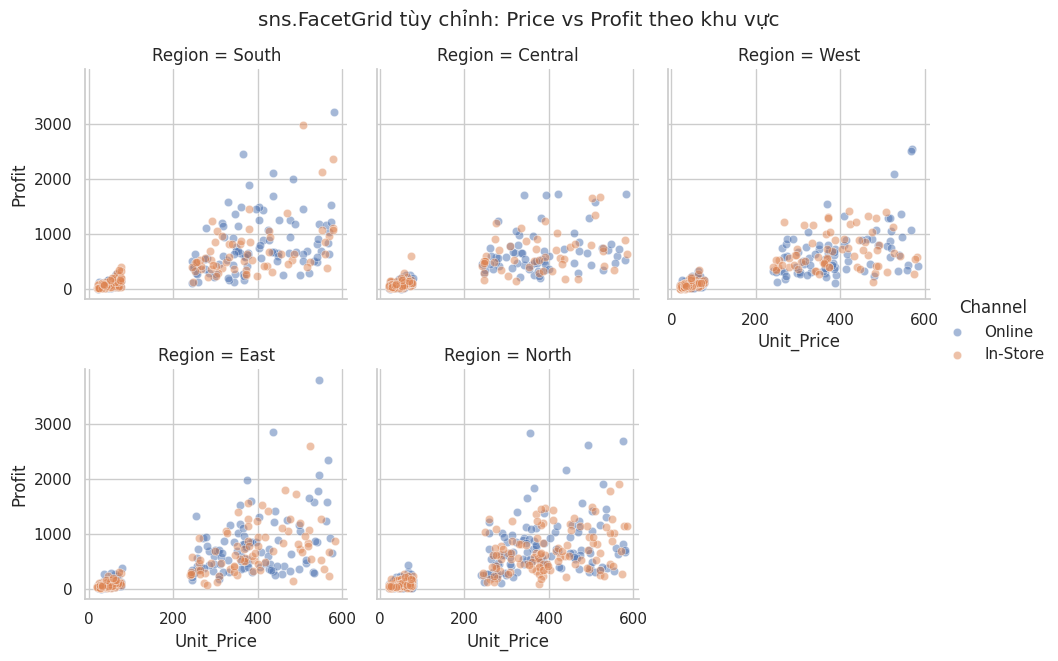

In [40]:
g = sns.FacetGrid(df, col="Region", col_wrap=3, height=3.2, hue="Channel")
g.map_dataframe(sns.scatterplot, x="Unit_Price", y="Profit", alpha=0.5)
g.add_legend()
g.fig.suptitle("sns.FacetGrid tùy chỉnh: Price vs Profit theo khu vực", y=1.03)
plt.show()

### 7.8 `sns.barplot` ngang + style nâng cao (top sản phẩm)

/tmp/ipykernel_474/2912655218.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="rocket")


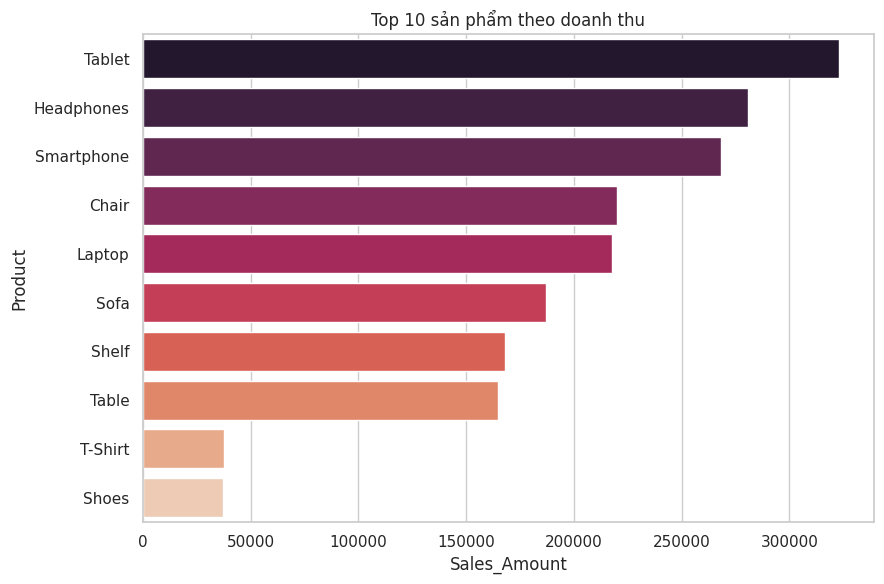

In [41]:
top_products = df.groupby("Product")["Sales_Amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette="rocket")
plt.title("Top 10 sản phẩm theo doanh thu")
plt.xlabel("Sales_Amount")
plt.tight_layout()
plt.show()

## 8. Tổng hợp style & theme hữu ích

```python
# Matplotlib style
plt.style.use("seaborn-v0_8-darkgrid")   # xem thêm: plt.style.available

# Seaborn theme
sns.set_theme(style="whitegrid", palette="viridis", font_scale=1.1)
sns.set_context("talk")   # "paper" | "notebook" | "talk" | "poster"

# Bảng màu seaborn thường dùng
sns.color_palette("deep")
sns.color_palette("husl", 8)
sns.color_palette("coolwarm", as_cmap=True)
```

Bạn có thể đổi các tham số `palette`, `style`, `context` ở đầu notebook để đồng bộ màu sắc cho toàn bộ biểu đồ.

## 9. Phụ lục: Script tạo dữ liệu mẫu

Đây là đoạn code đã dùng để tạo file `sample_sales_data.csv` (chỉ để tham khảo, **không cần chạy lại** vì file CSV đã có sẵn).

In [42]:
# --- Script tạo dữ liệu mẫu (tham khảo) ---
import numpy as np
import pandas as pd

np.random.seed(42)
n = 2000
dates = pd.date_range("2023-01-01", "2024-12-31", periods=n)

regions = ["North", "South", "East", "West", "Central"]
categories = ["Electronics", "Clothing", "Food", "Furniture", "Toys"]
products = {
    "Electronics": ["Laptop", "Smartphone", "Headphones", "Tablet"],
    "Clothing": ["T-Shirt", "Jeans", "Jacket", "Shoes"],
    "Food": ["Snacks", "Beverages", "Dairy", "Bakery"],
    "Furniture": ["Chair", "Table", "Sofa", "Shelf"],
    "Toys": ["Puzzle", "Action Figure", "Board Game", "Doll"],
}

region_arr = np.random.choice(regions, n, p=[0.25, 0.2, 0.2, 0.2, 0.15])
category_arr = np.random.choice(categories, n)
product_arr = np.array([np.random.choice(products[c]) for c in category_arr])

day_of_year = dates.dayofyear
seasonal = 1 + 0.4*np.sin((day_of_year/365)*2*np.pi + 1.5) + 0.3*(day_of_year > 330)

base_price = {"Electronics": 450, "Clothing": 60, "Food": 25, "Furniture": 300, "Toys": 40}
price_arr = np.array([base_price[c] for c in category_arr]) * np.random.uniform(0.8, 1.3, n)

quantity = np.random.poisson(lam=5, size=n) + 1
discount_pct = np.round(np.random.choice([0,5,10,15,20,25], n, p=[.35,.2,.2,.1,.1,.05]), 0)

sales_amount = price_arr * quantity * (1 - discount_pct/100) * seasonal
cost_ratio = np.random.uniform(0.55, 0.8, n)
profit = sales_amount * (1 - cost_ratio)

customer_age = np.clip(np.random.normal(38, 13, n), 18, 75).astype(int)
customer_rating = np.clip(np.random.normal(4.0, 0.8, n) + discount_pct*0.01 - 0.002*(customer_age-38), 1, 5).round(1)

payment_method = np.random.choice(["Credit Card","Cash","E-Wallet","Bank Transfer"], n, p=[.4,.2,.3,.1])
channel = np.random.choice(["Online","In-Store"], n, p=[.55,.45])

df_sample = pd.DataFrame({
    "Date": dates, "Region": region_arr, "Category": category_arr, "Product": product_arr,
    "Quantity": quantity, "Unit_Price": price_arr.round(2), "Discount_Percent": discount_pct,
    "Sales_Amount": sales_amount.round(2), "Profit": profit.round(2),
    "Customer_Age": customer_age, "Customer_Rating": customer_rating,
    "Payment_Method": payment_method, "Channel": channel,
})
# df_sample.to_csv("sample_sales_data.csv", index=False)
df_sample.head()

,Date,Region,Category,Product,Quantity,Unit_Price,Discount_Percent,Sales_Amount,Profit,Customer_Age,Customer_Rating,Payment_Method,Channel
0,2023-01-01 00:00:00.000000,South,Furniture,Table,6,348.92,0,2929.70,766.72,30,4.6,Cash,Online
1,2023-01-01 08:45:51.775887,Central,Food,Dairy,9,24.59,5,294.19,60.87,29,5.0,Credit Card,In-Store
2,2023-01-01 17:31:43.551775,West,Furniture,Chair,6,262.08,15,1870.51,752.79,47,4.8,E-Wallet,Online
3,2023-01-02 02:17:35.327663,East,Clothing,T-Shirt,6,54.20,5,432.41,181.30,21,4.8,Cash,In-Store
4,2023-01-02 11:03:27.103551,North,Clothing,Shoes,8,57.40,0,642.74,266.93,39,3.9,E-Wallet,In-Store
